# **1- Value class ve graphviz**

In [2]:
class Value:
  def __init__(self,data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self,):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      #self.grad = 1.0 * out.grad
      #other.grad = 1.0 * out.grad
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __radd__(self, other):
        return self + other

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += (other * self.data**(other-1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def tanh(self):
    n= self.data
    t = (np.exp(2*n)-1)/(np.exp(2*n)+1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(np.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

a = Value(3.0, label='a')
b = Value(-2.0,label='b')
c = Value(8.0,label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-4.0)

In [ ]:
d._op

'+'

In [ ]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))

    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      dot.node(name = uid + n._op, label = n._op)

      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


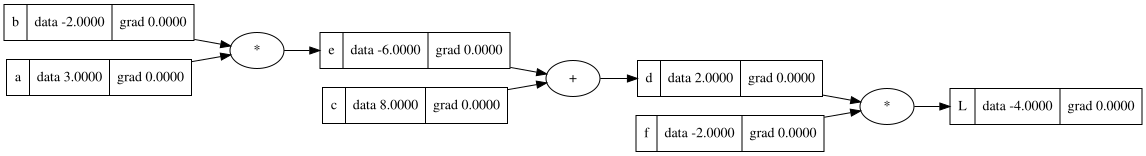

In [ ]:
draw_dot(L)

In [3]:
def lol():
  h = 0.001

  a = Value(3.0, label='a')
  b = Value(-2.0,label='b')
  c = Value(8.0,label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(3.0, label='a')
  b = Value(-2.0,label='b')
  c = Value(8.0,label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  d.data+=h
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2-L1)/h)

lol()

-1.9999999999997797


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

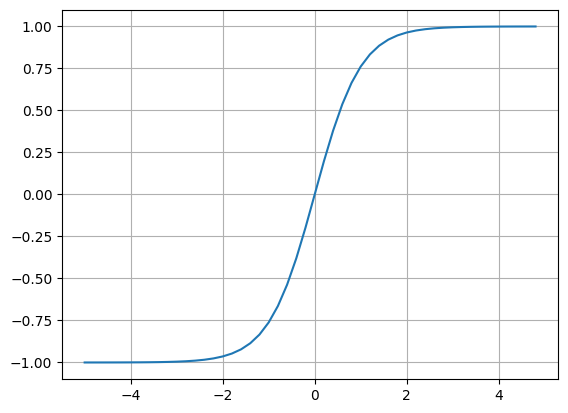

In [ ]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

In [ ]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [ ]:
o.grad = 1.0

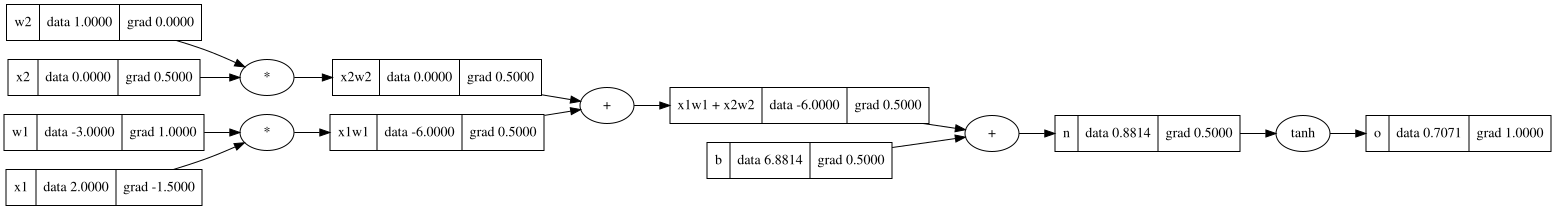

In [ ]:
draw_dot(o)

# **2- Manuel Backpropagation**

In [ ]:
x2.grad = w2.data * x2w2.grad
x1.grad =  w1.data * x1w1.grad

w2.grad = x2.data * x2w2.grad
w1.grad = x1.data * x1w1.grad

In [ ]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [ ]:
# + operatorüyle birleştirilmiş bir node'un gradı, çocuk node'lara doğrudan akar.
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [ ]:
n.grad = 0.5

In [ ]:
1 - o.data**2

np.float64(0.4999999999999999)

In [ ]:
o.data

np.float64(0.7071067811865476)

In [ ]:
# o = tanh(n)
# do/dn = 1 - o**2

# **3- backward()**

In [ ]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [ ]:
o.grad = 1.0

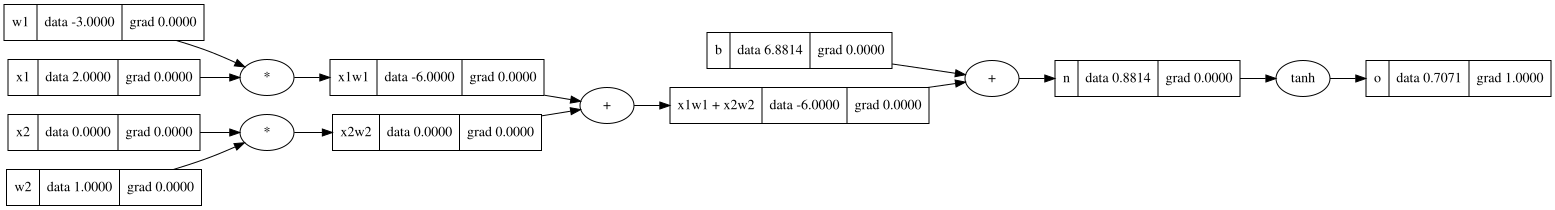

In [ ]:
draw_dot(o)

In [ ]:
o._backward()
n._backward()

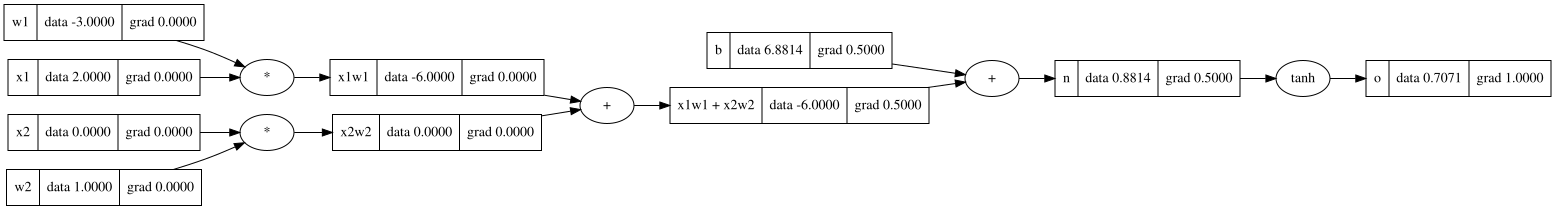

In [ ]:
draw_dot(o)

In [ ]:
# b._backward() leaf node olduğu için bir şey olmayacak. lambda : none yaptık cunku

In [ ]:
x1w1x2w2._backward()

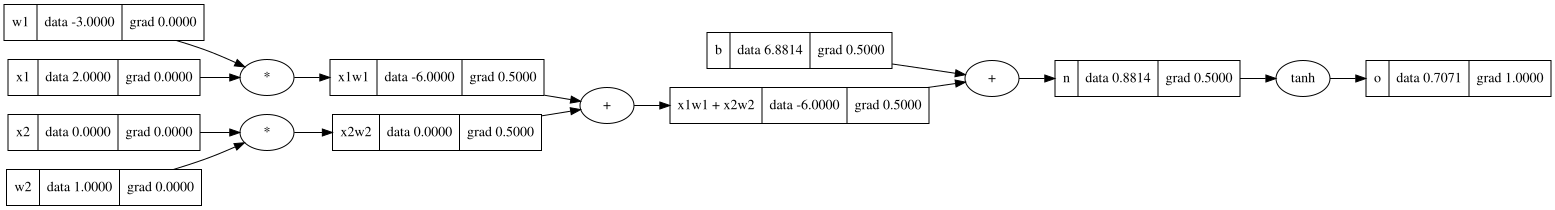

In [ ]:
draw_dot(o)

In [ ]:
x2w2._backward()
x1w1._backward()

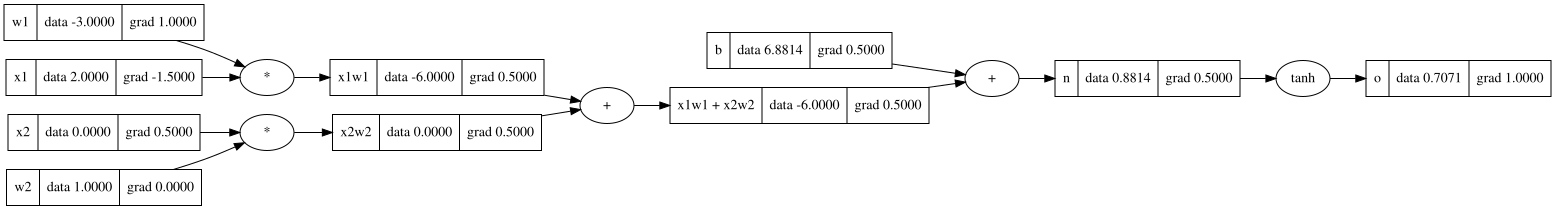

In [ ]:
draw_dot(o)

In [ ]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [ ]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [ ]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
  node._backward()

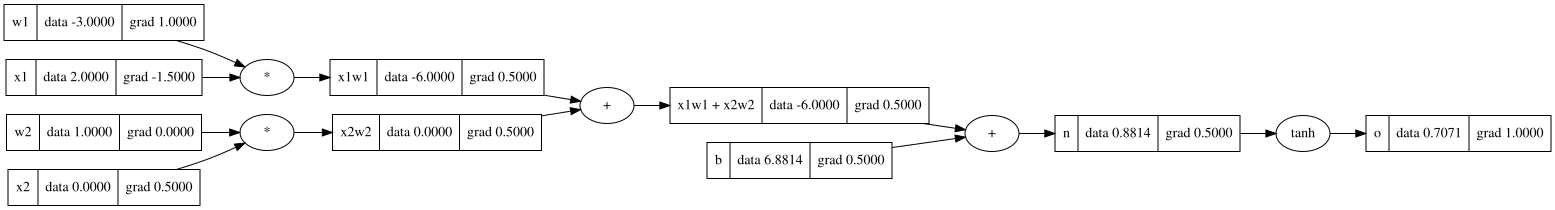

In [ ]:
draw_dot(o)
#şimdi value classına backward'ı fonksiyon olarak atayacağım ki her seferinde bu reversed topo ile uğraşmayayım.

In [ ]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

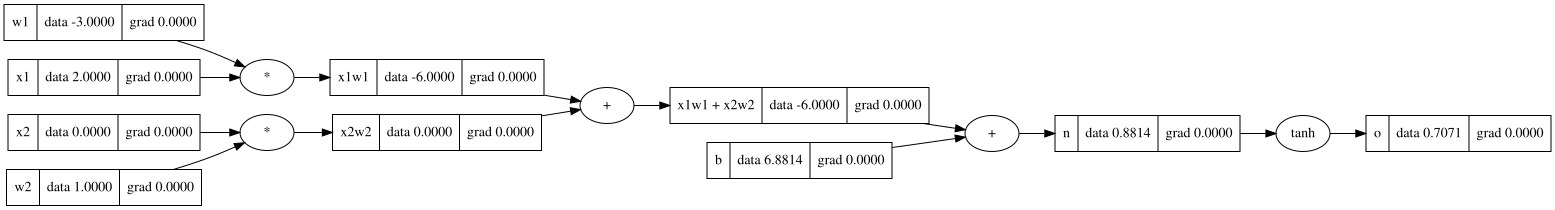

In [ ]:
draw_dot(o)

In [ ]:
o.backward()

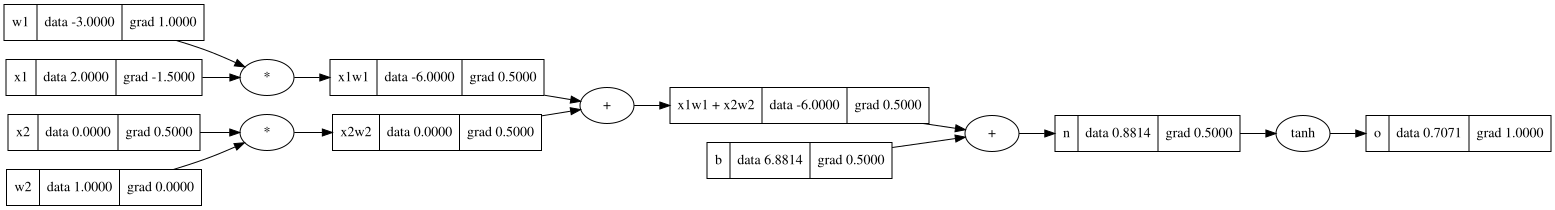

In [ ]:
draw_dot(o)

In [ ]:
#fakat burada her output'un grad'ını 1 olarak başlatarak bir hata yaptık.

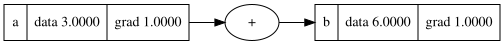

In [ ]:
#mesela :

a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

Fakat burada b = 2*a ve b nin a'ya göre türevi 1 değil, 2. işte burada her final output'un grad'ını 1'e set ederek bir hata yaptık. Biz bunu her değişkenin sadece 1 kere kullanılacağı durum için düşündük. ama bir değişkenin en az iki kere kullanıldığı (degisken a olsun.) senaryoda (yani bir inputun önündeki 2 neuron'a da beslenmesi durumu mesela) backward yaparken aynı grad'ı, a'ya birden fazla yazmış oluyoruz. Bu yüzden value class'ında ki _backward() fonksiyonlarında; self.grad ve other.grad fonksiyonlarını 1.0 * out.grad'a set etmek yerine; o fonksiyonlara "1.0 * out.grad"ı eklememiz lazım.      

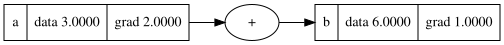

In [ ]:
# şimdi fonksiyonları düzelttikten sonra tekrar çalıştıralım
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

# **4- Tanh'ı parçalama ve 3 yöntemle de aynı olduğunu doğrulama**

In [ ]:
# şimdi biz a = Value (2.0) dedikten sonra, a + 1 i çalıştırırsak hata yeriz çünkü 1.data diye bir şey yok o yüzden onu düzeltelim. Bir de 2 * a yaptığımızda da hata verecek o yüzden rmul fonksiyonun oluşturucaz.

In [ ]:
a = Value(2.0)
b = Value(4.0)
print (a / b)
print(a - b)

Value(data=0.5)
Value(data=-2.0)


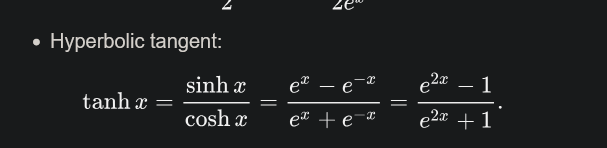

In [ ]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

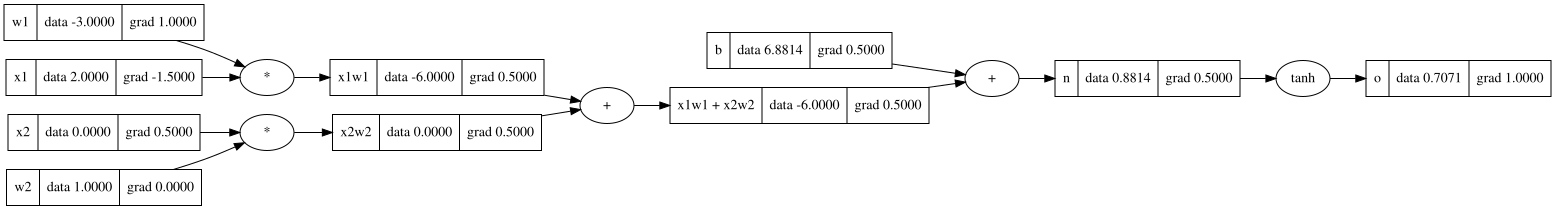

In [ ]:
draw_dot(o)

In [ ]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#tanh ı parçalıyoruz
e = (2*n).exp()
o = (e - 1) / (e + 1)
#---
o.label = 'o'
o.backward()

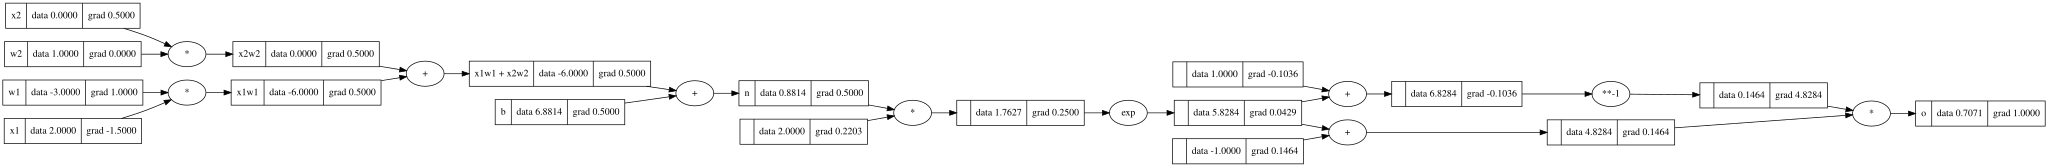

In [ ]:
draw_dot(o)
#aynı sonuc

In [ ]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
h = 0.001

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#tanh ı parçalıyoruz
e = (2*n).exp()
o = (e - 1) / (e + 1)
#---
o.label = 'o'

#-------------------------------------------------

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0 + h, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#tanh ı parçalıyoruz
e = (2*n).exp()
o1 = (e - 1) / (e + 1)
#---
o1.label = 'o1'

#-------------------------------------------------

x1 = Value(2.0 + h, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#tanh ı parçalıyoruz
e = (2*n).exp()
o2 = (e - 1) / (e + 1)
#---
o2.label = 'o2'

#-------------------------------------------------

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0 + h, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#tanh ı parçalıyoruz
e = (2*n).exp()
o3 = (e - 1) / (e + 1)
#---
o3.label = 'o3'

#-------------------------------------------------

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0 + h, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#tanh ı parçalıyoruz
e = (2*n).exp()
o4 = (e - 1) / (e + 1)
#---
o4.label = 'o4'

#-------------------------------------------------

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432 + h, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#tanh ı parçalıyoruz
e = (2*n).exp()
o5 = (e - 1) / (e + 1)
#---
o5.label = 'o5'


In [ ]:
w1_grad = (o1 - o) / h
x1_grad = (o2 - o) / h
w2_grad = (o3 - o) / h
x2_grad = (o4 - o) / h
b_grad = (o5 - o) / h

print('w1_grad', w1_grad)
print('x1_grad', x1_grad)
print('w2_grad', w2_grad)
print('x2_grad', x2_grad)
print('b_grad', b_grad)

w1_grad Value(data=0.9985864540449363)
x1_grad Value(data=-1.5031842257283712)
w2_grad Value(data=0.0)
x2_grad Value(data=0.4996465300016739)
b_grad Value(data=0.4996465300016739)


# **HEPSİ AYNIIII!!!**

# **5- Neuron, Layer ve MLP sınıflarının kurulumu**

In [4]:
import random
import numpy as np
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [8]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=-0.9949066033862842)

In [11]:
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(data=-0.5962514640122072),
 Value(data=0.40771691086825057),
 Value(data=0.9908537242236382)]

In [21]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.8746488257616419)

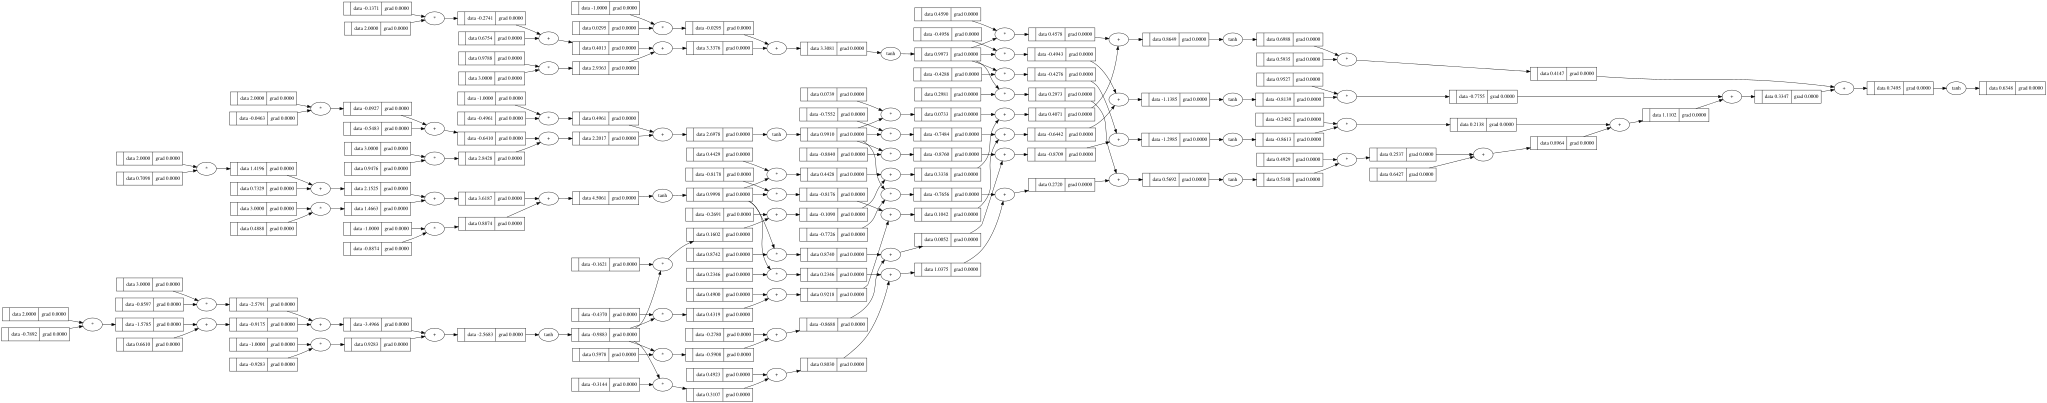

In [ ]:
draw_dot(n(x))

In [20]:
xs = [
  [2.0, 2.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # istenen cikti

ypred = [n(x) for x in xs]
ypred


[Value(data=0.9999998176269469),
 Value(data=-0.9999999990686939),
 Value(data=-0.9999999959564163),
 Value(data=0.9999998253639186)]

In [ ]:
[(yout - ygt)**2 for ygt, yout in zip(ys,ypred)]

[Value(data=0.22364658638334192),
 Value(data=0.6876170673417333),
 Value(data=0.451163263149683),
 Value(data=0.6049970927867414)]

In [ ]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=1.9674240096614997)

In [ ]:
loss.backward()

In [ ]:
n.layers[0].neurons[0].w[0].grad

np.float64(-0.704601010172957)

In [ ]:
n.parameters()

[Value(data=0.8709318849642649),
 Value(data=-0.6802507382870626),
 Value(data=0.9246404751531094),
 Value(data=-0.4842447307115194),
 Value(data=-0.8529821204845873),
 Value(data=-0.741479288173404),
 Value(data=-0.7306602469473029),
 Value(data=-0.5999805771186031),
 Value(data=-0.825646599585516),
 Value(data=0.06384587493473837),
 Value(data=-0.05046542808226406),
 Value(data=0.8600964578968586),
 Value(data=-0.45913735574291104),
 Value(data=-0.06038381255946046),
 Value(data=0.3115913359693143),
 Value(data=0.50512556414145),
 Value(data=0.6006190941742022),
 Value(data=-0.4511745969285994),
 Value(data=0.18100582640810203),
 Value(data=-0.3598454999275782),
 Value(data=0.6586112659340035),
 Value(data=-0.4830394134792799),
 Value(data=0.24896489690854318),
 Value(data=0.22303508046218412),
 Value(data=-0.19559562803958142),
 Value(data=0.8735877528766345),
 Value(data=-0.4263295198399244),
 Value(data=0.7970480990992805),
 Value(data=-0.05510204887497139),
 Value(data=0.88035326

In [ ]:
len(n.parameters())

41

In [ ]:
draw_dot(loss)

In [ ]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=1.2812306271210452)

In [ ]:
loss.backward()

In [ ]:
for p in n.parameters():
  p.data += -0.05 * p.grad

In [22]:
lr = 0.05

for k in range(20):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  #backward
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  #update parameters
  for p in n.parameters():
    p.data += -lr * p.grad

  print(k, loss.data)


0 4.777957845919612
1 1.28068429278694
2 0.714074120058862
3 0.41107924869649604
4 0.27286228453060407
5 0.20288931197242718
6 0.16043108440474574
7 0.13206004712950914
8 0.11190139004313657
9 0.09690368103373344
10 0.08534233136217476
11 0.07617568396611521
12 0.06874017452195441
13 0.0625943397606898
14 0.05743371550718859
15 0.05304186706680808
16 0.049260916183606854
17 0.045973109428126296
18 0.043088904505612695
19 0.0405390449711777
